In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 195 (delta 92), reused 147 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (195/195), 1.32 MiB | 4.32 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/miniml


In [2]:
from miniml.knn.knnregressor import KNNRegression

In [3]:
# %% [Cell 1] — Imports & Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Генерация данных: синусоида с шумом
np.random.seed(42)
X_train = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, 100)
X_test = np.linspace(0, 10, 100).reshape(-1, 1)

# %% [Cell 2] — Проверка 'classic' vs Sklearn (Uniform)
# Sklearn
sk_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='euclidean')
sk_reg.fit(X_train, y_train)
y_sk = sk_reg.predict(X_test)

# Твой класс (classic режим)
my_reg = KNNRegression(neighbours=5, metric='euclid', regression_type='classic')
my_reg.fit(X_train, y_train)
y_my = my_reg.predict(X_test)

# Assert
mse_diff = mean_squared_error(y_sk, y_my)
print(f"MSE разница между sklearn и твоим классик-режимом: {mse_diff:.6e}")
assert mse_diff < 1e-10, "Результаты классической регрессии не совпадают!"
print("Classic mode успешно прошел проверку по Sklearn.")

MSE разница между sklearn и твоим классик-режимом: 0.000000e+00
Classic mode успешно прошел проверку по Sklearn.


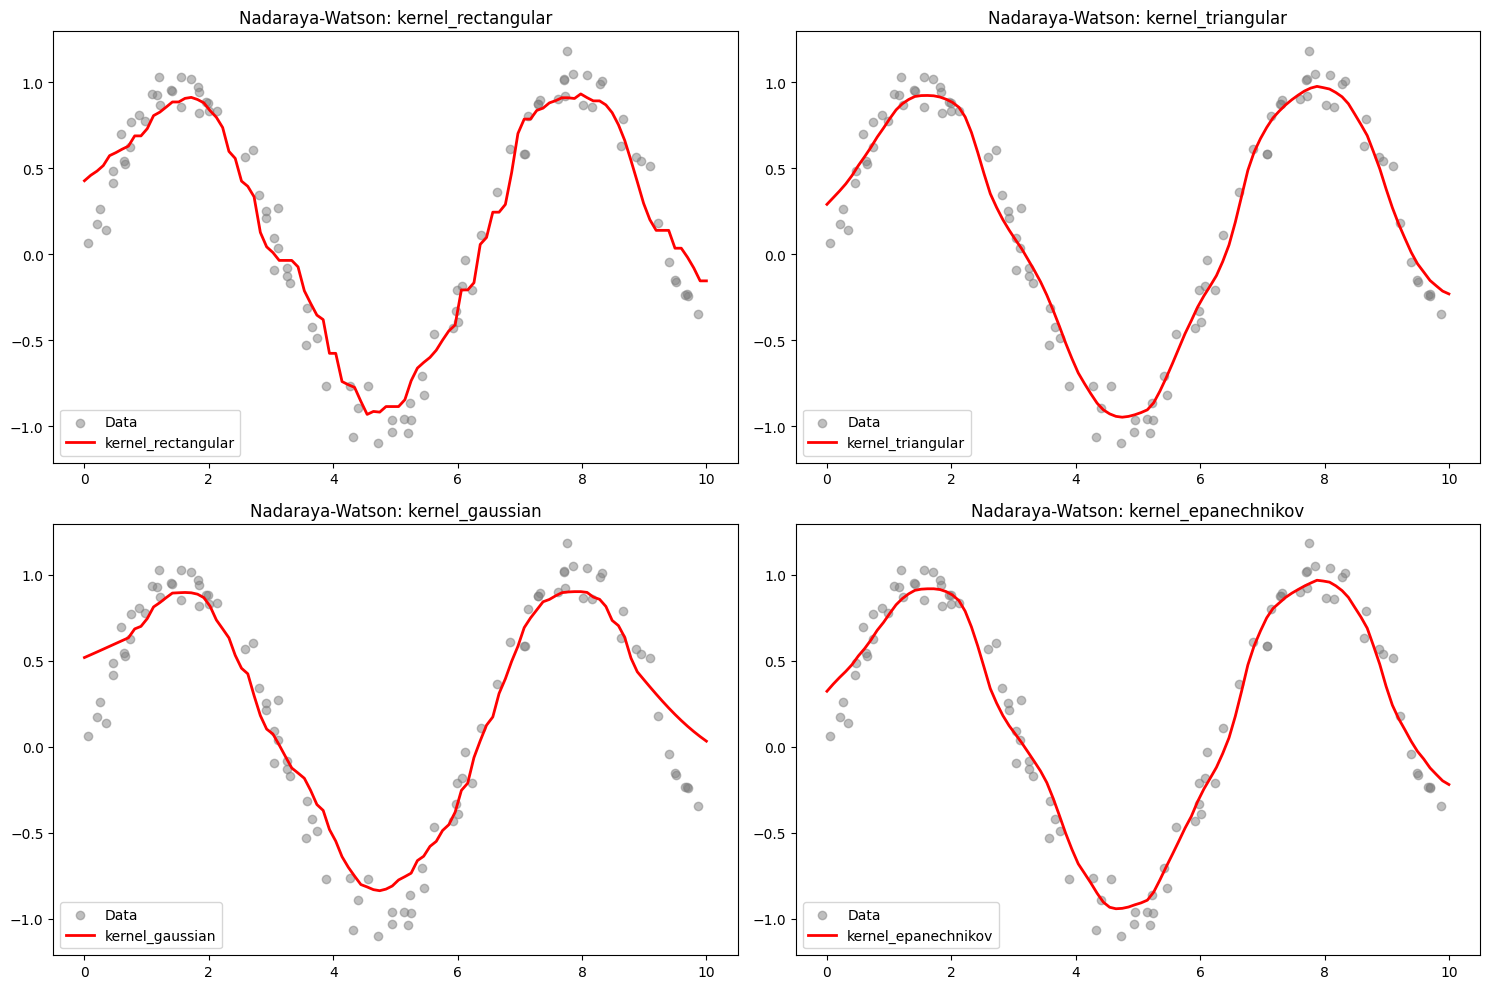

In [4]:
# %% [Cell 3] — Визуализация работы ядер
kernels = ['kernel_rectangular', 'kernel_triangular', 'kernel_gaussian', 'kernel_epanechnikov']
h_values = [0.5, 1.5] # Попробуй поменять bandwidth для разного сглаживания

plt.figure(figsize=(15, 10))

for i, kernel_name in enumerate(kernels):
    plt.subplot(2, 2, i+1)

    # Регрессия с разными ядрами
    reg = KNNRegression(neighbours=20, weight_type=kernel_name,
                        regression_type='nadaraya_watson', h=0.8)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Data')
    plt.plot(X_test, y_pred, color='red', linewidth=2, label=f'{kernel_name}')
    plt.title(f'Nadaraya-Watson: {kernel_name}')
    plt.legend()

plt.tight_layout()
plt.show()